# Imports 

In [1]:
import pandas as pd
from collections import defaultdict
import sys
import os
import shutil as sh
import urllib
import tarfile
import numpy as np
import math
import seaborn as sns
import glob, os
import importlib
import gzip
import MDAnalysis as mda
import nglview as nv
import requests
import json
from biopandas.pdb import PandasPdb
from Bio import AlignIO
import re
from io import StringIO
import itertools

from sklearn.calibration import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, roc_auc_score

from sklearn.naive_bayes import CategoricalNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.spatial import ConvexHull

# Methods 

In [3]:
from sklearn.feature_selection import r_regression


def load_data(path):
    """
    Load data from the path were it was stored.
    """
    if not os.path.isfile(path):
        raise FileNotFoundError(f"The file at {path} was not found.")
    return pd.read_csv(path)

def separate_features_target(df, target, columns_to_remove=None):
    if columns_to_remove is None:
        columns_to_remove=[]
    columns_to_remove=set(columns_to_remove + [target])
    X=df.drop(columns=[col for col in columns_to_remove if col in df.columns])
    y=df[target]
    return X, y


def select_features(X, y, threshold=0.1):
    correlations = pd.Series(r_regression(X, y), index=X.columns)
    selected_features = correlations[correlations.abs() >= threshold].index.tolist()
    print(f"The selected features of {X.shape[1]} were: {len(selected_features)}")
    return selected_features, correlations

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    matthews_corrcoef
)

def train_tuned_model(
    model,
    X_train,
    X_test,
    y_train,
    y_test,
    cmap="Blues",
    scale=True
):
    """
    Train and evaluate a tuned model using:
      - Confusion matrix (plotted as heatmap)
      - AUC (if applicable)
      - Matthews Correlation Coefficient (MCC)

    Returns:
      auc (float or None), mcc (float), y_test, y_pred
    """
    if scale:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test  = scaler.transform(X_test)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    cm_df = pd.DataFrame(
        cm,
        index=["Actual: 0", "Actual: 1"],
        columns=["Predicted: 0", "Predicted: 1"]
    )
    plt.figure(figsize=(5,4))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap=cmap)
    plt.title(f"{model.__class__.__name__} Confusion Matrix")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.show()

    auc = None
    if hasattr(model, "predict_proba"):
        try:
            y_prob = model.predict_proba(X_test)[:,1]
            auc = roc_auc_score(y_test, y_prob)
            print(f"AUC: {auc:.4f}")
        except Exception:
            print("AUC could not be computed from probabilities.")
    else:
        try:
            auc = roc_auc_score(y_test, y_pred)
            print(f"AUC (label‐based): {auc:.4f}")
        except ValueError:
            print("AUC could not be computed (only one class predicted).")

    
    mcc = matthews_corrcoef(y_test, y_pred)
    print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")

    return auc, mcc, y_test, y_pred



# Load Data

In [4]:
df = load_data("/home/user_stel/AISB/Project/dataset/processed_dataset.csv")
print(df)

       domain  residue_name  IBS  residue_number  convhull_vertex  \
0          PH           2.0  0.0            19.0              0.0   
1          PH           2.0  0.0            75.0              1.0   
2          PH           2.0  0.0            78.0              1.0   
3          PH           2.0  0.0            92.0              1.0   
4          PH           2.0  0.0            93.0              1.0   
...       ...           ...  ...             ...              ...   
183885    PLA           4.0  0.0            91.0              0.0   
183886    PLA           4.0  0.0            96.0              0.0   
183887    PLA           4.0  0.0            98.0              0.0   
183888    PLA           4.0  0.0           105.0              0.0   
183889    PLA           4.0  1.0           124.0              0.0   

        is_hydrophobic_protrusion  is_co_insertable  exposed  type  
0                             0.0               0.0      1.0   4.0  
1                             0.0

In [5]:
# split features and target 
columns_to_remove = ['domain', 'residue_number']
X, y = separate_features_target(df, target='IBS', columns_to_remove=columns_to_remove)

# Feature Correlation Analysis 

The selected features of 6 were: 2
['convhull_vertex', 'exposed']
        convhull_vertex  exposed  IBS
0                   0.0      1.0  0.0
1                   1.0      1.0  0.0
2                   1.0      1.0  0.0
3                   1.0      1.0  0.0
4                   1.0      1.0  0.0
...                 ...      ...  ...
183885              0.0      0.0  0.0
183886              0.0      0.0  0.0
183887              0.0      0.0  0.0
183888              0.0      1.0  0.0
183889              0.0      1.0  1.0

[183890 rows x 3 columns]


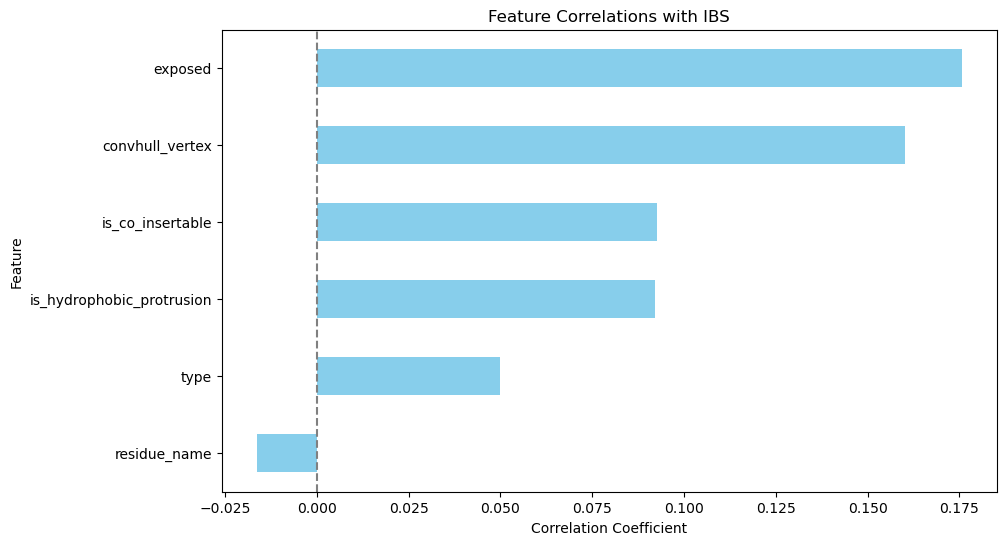

In [7]:
selected_features, correlations=select_features(X, y, threshold=0.1)
                                        
print(selected_features)

# Creates a new dataset that contains only the selected features 
X_selected=X[selected_features]
#print(X_selected)

selected_feature_names = X_selected.columns.tolist()
target = 'IBS'
selected_df = df[selected_feature_names + [target]]
print(selected_df)

plt.figure(figsize=(10, 6))
correlations.sort_values().plot(kind='barh', color='skyblue')
plt.title("Feature Correlations with IBS")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")
plt.axvline(0, color='grey', linestyle='--')
plt.show()

# Hyperparameter Tuning

In [8]:
models = {
    'LogisticRegression-elasticnet': LogisticRegression(
        penalty='elasticnet', solver='saga', random_state=0, max_iter=10000
    ),
    'RandomForest': RandomForestClassifier(random_state=0),
    'CategoricalNB': CategoricalNB(),
    'XGBoost' : XGBClassifier()
    }

In [10]:
# Your dictionary of hyperparameters
param_grid = {
    'LogisticRegression-elasticnet': {
        'C': [0.01, 0.1, 1, 10],
        'l1_ratio': [0.0, 0.25, 0.5, 0.75, 1.0],
        'penalty': ['elasticnet'],
        'solver': ['saga'],
        'max_iter': [10000]  # Needed for convergence in elasticnet
    },
    'RandomForest': {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    },
    'CategoricalNB': {
        'alpha': [0.0, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
    },
    'XGBoost' : {
        'n_estimators':    [100, 200],
        'max_depth':       [3, 6, 9],
        'learning_rate':   [0.01, 0.1, 0.2],
        'subsample':       [0.7, 1.0],
        'colsample_bytree':[0.7, 1.0],
        'use_label_encoder':[False],      # suppress warning in recent versions
        'eval_metric':     ['logloss']    # required when use_label_encoder=False
    }
}

# Mapping names to classifier constructors
models = {
    'LogisticRegression-elasticnet': LogisticRegression,
    'RandomForest': RandomForestClassifier,
    'CategoricalNB': CategoricalNB,
    'XGBoost': XGBClassifier
}

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Store all results
grid_results = {}

# Loop through each model + param set
for name, params in param_grid.items():
    print(f"Running GridSearchCV for {name}...")

    model = models[name]()  # Create the model
    clf = GridSearchCV(estimator=model, param_grid=params, cv=5, scoring='accuracy', n_jobs=-1)
    
    clf.fit(X_train, y_train)
    
    # Save results
    grid_results[name] = {
        'best_estimator': clf.best_estimator_,
        'best_params': clf.best_params_,
        'best_score': clf.best_score_,
        'cv_results': clf.cv_results_
    }

for name, result in grid_results.items():
    print(f"===== {name} =====")
    print("Best params:", result['best_params'])
    print("Best CV score:", result['best_score'])
    print("  (click below to see full cv_results_ as a table)")
    df_cv = pd.DataFrame(result['cv_results'])
    display(df_cv)    # Collapsible DataFrame for each model
    print("\n")


Running GridSearchCV for LogisticRegression-elasticnet...
Running GridSearchCV for RandomForest...
Running GridSearchCV for CategoricalNB...
Running GridSearchCV for XGBoost...


/home/user_stel/miniconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:01:51] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/user_stel/miniconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:01:51] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/user_stel/miniconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:01:51] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/user_stel/miniconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:01:51] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/user_stel/miniconda3/lib/pytho

===== LogisticRegression-elasticnet =====
Best params: {'C': 1, 'l1_ratio': 0.0, 'max_iter': 10000, 'penalty': 'elasticnet', 'solver': 'saga'}
Best CV score: 0.8486284474674586
  (click below to see full cv_results_ as a table)


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_l1_ratio,param_max_iter,param_penalty,param_solver,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,1.415940,0.131742,0.009253,0.001206,0.01,0.00,10000,elasticnet,saga,"{'C': 0.01, 'l1_ratio': 0.0, 'max_iter': 10000...",0.848359,0.848359,0.848359,0.848392,0.848392,0.848372,0.000016,16
1,1.611233,0.167028,0.008996,0.000527,0.01,0.25,10000,elasticnet,saga,"{'C': 0.01, 'l1_ratio': 0.25, 'max_iter': 1000...",0.848359,0.848359,0.848359,0.848392,0.848392,0.848372,0.000016,16
2,1.646595,0.070083,0.007849,0.000880,0.01,0.50,10000,elasticnet,saga,"{'C': 0.01, 'l1_ratio': 0.5, 'max_iter': 10000...",0.848359,0.848359,0.848359,0.848392,0.848392,0.848372,0.000016,16
3,1.613623,0.140374,0.008615,0.001354,0.01,0.75,10000,elasticnet,saga,"{'C': 0.01, 'l1_ratio': 0.75, 'max_iter': 1000...",0.848359,0.848359,0.848359,0.848392,0.848392,0.848372,0.000016,16
4,1.788244,0.146553,0.006991,0.000929,0.01,1.00,10000,elasticnet,saga,"{'C': 0.01, 'l1_ratio': 1.0, 'max_iter': 10000...",0.848359,0.848359,0.848359,0.848392,0.848392,0.848372,0.000016,16
5,1.442600,0.112944,0.007565,0.001092,0.10,0.00,10000,elasticnet,saga,"{'C': 0.1, 'l1_ratio': 0.0, 'max_iter': 10000,...",0.848359,0.848320,0.848592,0.848547,0.848353,0.848434,0.000112,11
6,1.681136,0.060090,0.007747,0.000541,0.10,0.25,10000,elasticnet,saga,"{'C': 0.1, 'l1_ratio': 0.25, 'max_iter': 10000...",0.848359,0.848320,0.848592,0.848547,0.848353,0.848434,0.000112,11
7,1.688906,0.127508,0.008125,0.001233,0.10,0.50,10000,elasticnet,saga,"{'C': 0.1, 'l1_ratio': 0.5, 'max_iter': 10000,...",0.848359,0.848320,0.848592,0.848547,0.848353,0.848434,0.000112,11
8,1.723856,0.094880,0.008740,0.000753,0.10,0.75,10000,elasticnet,saga,"{'C': 0.1, 'l1_ratio': 0.75, 'max_iter': 10000...",0.848359,0.848320,0.848592,0.848547,0.848353,0.848434,0.000112,11
9,1.762708,0.147388,0.008935,0.001103,0.10,1.00,10000,elasticnet,saga,"{'C': 0.1, 'l1_ratio': 1.0, 'max_iter': 10000,...",0.848359,0.848320,0.848592,0.848547,0.848353,0.848434,0.000112,11




===== RandomForest =====
Best params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Best CV score: 0.8491644835366609
  (click below to see full cv_results_ as a table)


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_leaf,param_min_samples_split,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,13.128535,2.087648,0.561169,0.133964,None,1,2,100,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",0.849680,0.849019,0.84898,0.849208,0.848897,0.849157,0.000281,3
1,28.405277,4.231058,1.307715,0.194175,None,1,2,200,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",0.849369,0.849019,0.84898,0.849208,0.848897,0.849095,0.000171,20
2,13.350846,3.094078,0.677657,0.168209,None,1,5,100,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",0.849369,0.849019,0.84898,0.849208,0.848897,0.849095,0.000171,20
3,23.600076,4.033493,1.238592,0.367664,None,1,5,200,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",0.849446,0.849019,0.84898,0.849208,0.848897,0.849110,0.000197,10
4,10.811182,2.451237,0.538877,0.120159,None,2,2,100,"{'max_depth': None, 'min_samples_leaf': 2, 'mi...",0.849602,0.849019,0.84898,0.849208,0.848936,0.849149,0.000245,4
5,26.524087,4.817470,1.354168,0.236368,None,2,2,200,"{'max_depth': None, 'min_samples_leaf': 2, 'mi...",0.849602,0.849019,0.84898,0.849208,0.848936,0.849149,0.000245,4
6,11.258826,1.791544,0.503185,0.117050,None,2,5,100,"{'max_depth': None, 'min_samples_leaf': 2, 'mi...",0.849602,0.849019,0.84898,0.849208,0.848936,0.849149,0.000245,4
7,22.171826,5.825245,1.090893,0.322069,None,2,5,200,"{'max_depth': None, 'min_samples_leaf': 2, 'mi...",0.849602,0.849019,0.84898,0.849208,0.848936,0.849149,0.000245,4
8,12.440222,2.332016,0.632415,0.138804,10,1,2,100,"{'max_depth': 10, 'min_samples_leaf': 1, 'min_...",0.849369,0.849019,0.84898,0.849208,0.848858,0.849087,0.000180,23
9,24.919391,3.905782,1.358817,0.276297,10,1,2,200,"{'max_depth': 10, 'min_samples_leaf': 1, 'min_...",0.849369,0.849019,0.84898,0.849208,0.848897,0.849095,0.000171,20




===== CategoricalNB =====
Best params: {'alpha': 0.0}
Best CV score: 0.8473310933920566
  (click below to see full cv_results_ as a table)


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.033666,0.003361,0.009124,0.001524,0.0,{'alpha': 0.0},0.848048,0.846922,0.846689,0.84777,0.847227,0.847331,0.000510,1
1,0.031810,0.003014,0.006929,0.000627,0.1,{'alpha': 0.1},0.848048,0.846922,0.846689,0.84777,0.847227,0.847331,0.000510,1
2,0.030520,0.001800,0.007125,0.000560,0.5,{'alpha': 0.5},0.848048,0.846922,0.846689,0.84777,0.847227,0.847331,0.000510,1
3,0.033898,0.002185,0.008013,0.001859,1.0,{'alpha': 1.0},0.848048,0.846922,0.846689,0.84777,0.847227,0.847331,0.000510,1
4,0.032165,0.004075,0.007836,0.000892,2.0,{'alpha': 2.0},0.848048,0.846922,0.846689,0.84777,0.847227,0.847331,0.000510,1
5,0.031149,0.001709,0.008103,0.001567,5.0,{'alpha': 5.0},0.848048,0.846922,0.846689,0.84777,0.847227,0.847331,0.000510,1
6,0.032993,0.002457,0.008094,0.001080,10.0,{'alpha': 10.0},0.847388,0.846922,0.846689,0.84711,0.847227,0.847067,0.000243,7




===== XGBoost =====
Best params: {'colsample_bytree': 0.7, 'eval_metric': 'logloss', 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.7, 'use_label_encoder': False}
Best CV score: 0.8491722535441966
  (click below to see full cv_results_ as a table)


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_colsample_bytree,param_eval_metric,param_learning_rate,param_max_depth,param_n_estimators,param_subsample,param_use_label_encoder,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,1.699911,0.056368,0.068492,0.004654,0.7,logloss,0.01,3,100,0.7,False,"{'colsample_bytree': 0.7, 'eval_metric': 'logl...",0.848359,0.848359,0.848359,0.848392,0.848392,0.848372,0.000016,57
1,1.596694,0.061999,0.067254,0.002829,0.7,logloss,0.01,3,100,1.0,False,"{'colsample_bytree': 0.7, 'eval_metric': 'logl...",0.848359,0.848359,0.848359,0.848392,0.848392,0.848372,0.000016,57
2,3.622391,0.146340,0.137399,0.027419,0.7,logloss,0.01,3,200,0.7,False,"{'colsample_bytree': 0.7, 'eval_metric': 'logl...",0.848359,0.848359,0.848359,0.848392,0.848392,0.848372,0.000016,57
3,3.323159,0.046268,0.160263,0.030029,0.7,logloss,0.01,3,200,1.0,False,"{'colsample_bytree': 0.7, 'eval_metric': 'logl...",0.848359,0.848359,0.848359,0.848392,0.848392,0.848372,0.000016,57
4,2.784427,0.279192,0.201496,0.007695,0.7,logloss,0.01,6,100,0.7,False,"{'colsample_bytree': 0.7, 'eval_metric': 'logl...",0.848359,0.848359,0.848359,0.848392,0.848392,0.848372,0.000016,57
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,5.350760,0.151020,0.464631,0.035152,1.0,logloss,0.20,6,200,1.0,False,"{'colsample_bytree': 1.0, 'eval_metric': 'logl...",0.849446,0.849019,0.849019,0.849246,0.848897,0.849126,0.000196,15
68,3.725851,0.256450,0.456955,0.044809,1.0,logloss,0.20,9,100,0.7,False,"{'colsample_bytree': 1.0, 'eval_metric': 'logl...",0.849369,0.849019,0.848980,0.849208,0.848858,0.849087,0.000180,46
69,3.117402,0.178921,0.393003,0.051979,1.0,logloss,0.20,9,100,1.0,False,"{'colsample_bytree': 1.0, 'eval_metric': 'logl...",0.849369,0.849019,0.849019,0.849246,0.848897,0.849110,0.000172,26
70,6.857113,0.353470,0.574374,0.083661,1.0,logloss,0.20,9,200,0.7,False,"{'colsample_bytree': 1.0, 'eval_metric': 'logl...",0.849369,0.849019,0.848980,0.849208,0.848858,0.849087,0.000180,46


# Train tuned models 


Evaluating best model for: LogisticRegression-elasticnet


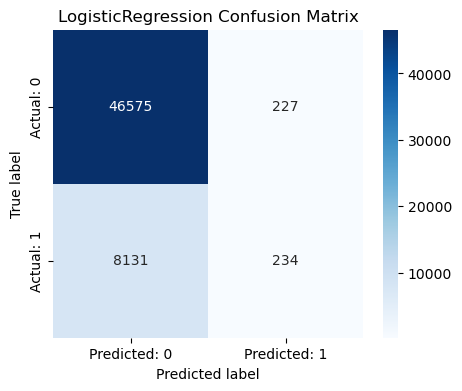

AUC: 0.6543
Matthews Correlation Coefficient (MCC): 0.0911

Evaluating best model for: RandomForest


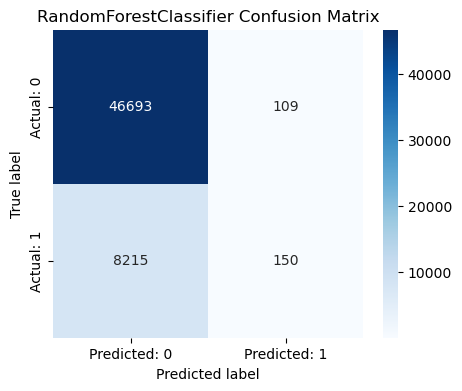

AUC: 0.6842
Matthews Correlation Coefficient (MCC): 0.0819

Evaluating best model for: CategoricalNB


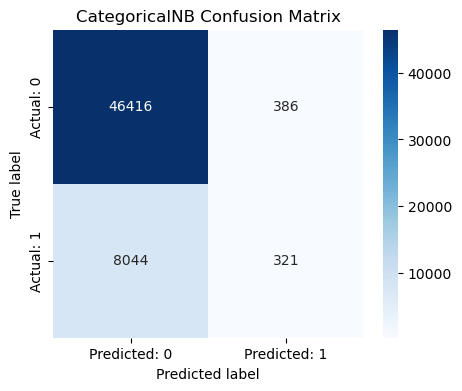

AUC: 0.6734
Matthews Correlation Coefficient (MCC): 0.0961

Evaluating best model for: XGBoost


/home/user_stel/miniconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:05:44] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


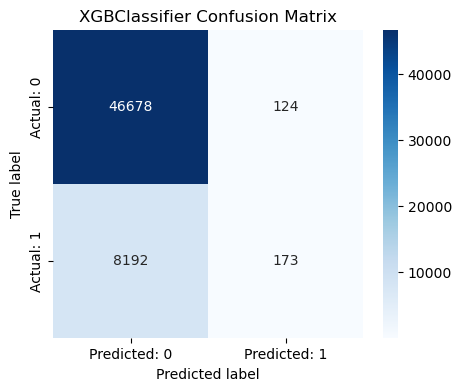

AUC: 0.6825
Matthews Correlation Coefficient (MCC): 0.0884

MCC Summary:
                           Model       MCC
2                  CategoricalNB  0.096066
0  LogisticRegression-elasticnet  0.091107
3                        XGBoost  0.088382
1                   RandomForest  0.081866


In [11]:
model_mcc_scores = []

for model_name, result in grid_results.items():
    best_model = result['best_estimator']
    print(f"\nEvaluating best model for: {model_name}")
    scale_flag = model_name.startswith("Logistic")
    
    auc, mcc, y_test, y_pred = train_tuned_model(
        best_model, X_train, X_test, y_train, y_test, scale=False
    )
    
    model_mcc_scores.append({
        'Model': model_name,
        'MCC': mcc
    })

# Create DataFrame
mcc_summary_df = pd.DataFrame(model_mcc_scores)
print("\nMCC Summary:")
print(mcc_summary_df.sort_values(by='MCC', ascending=False))

# Build Predicted Dataset

In [12]:
AATYPE = {
    "LEU": "Hydrophobic,H-non-aromatic",
    "ILE": "Hydrophobic,H-non-aromatic",
    "CYS": "Hydrophobic,H-non-aromatic",
    "MET": "Hydrophobic,H-non-aromatic",
    "TYR": "Hydrophobic,H-aromatic",
    "TRP": "Hydrophobic,H-aromatic",
    "PHE": "Hydrophobic,H-aromatic",
    "HIS": "Polar",
    "LYS": "Positive",
    "ARG": "Positive",
    "ASP": "Negative",
    "GLU": "Negative",
    "VAL": "Non-polar",
    "ALA": "Non-polar",
    "SER": "Polar",
    "ASN": "Polar",
    "GLY": "Non-polar",
    "PRO": "Non-polar",
    "GLN": "Polar",
    "THR": "Polar",
    "UNK": "none"
}

In [ ]:
df_test_pred = X_test.copy()
df_test_pred['IBS_pred'] = y_pred.astype(int)   # 0 or 1

print(df_test_pred.head())

        residue_name  convhull_vertex  is_hydrophobic_protrusion  \
71217            8.0              1.0                        0.0   
170632          16.0              1.0                        0.0   
55363           10.0              0.0                        0.0   
41382            9.0              0.0                        0.0   
25295           18.0              1.0                        1.0   

        is_co_insertable  exposed  type  IBS_pred  
71217                0.0      1.0   4.0         0  
170632               0.0      1.0   4.0         0  
55363                0.0      1.0   1.0         0  
41382                0.0      0.0   1.0         0  
25295                0.0      1.0   0.0         0  


In [21]:
def pct_composition(df, group_col, count_col):
    ct  = df.groupby([group_col, count_col]).size().unstack(fill_value=0)
    pct = ct.div(ct.sum(axis=1), axis=0) * 100
    return pct